# Model Development

<span style="color:red">**Note:** </span>This notebook is paired with a Python script using **Jupytext**.  
 - The `.ipynb` is the primary artifact for exploration and explanation.  
 - A synchronized `.py` file is maintained for reproducibility and review.  
 - To manually sync all notebooks, run the alias `syncnb`.  
 - The project does not require Jupytext to run; the paired `.py` files are already committed.


<h2 style="color:cyan">1. Feature Engineering</h2>

 1. Setup: load data via DuckDB, load feature set from exploration
 2. Define offset map for 24h temporal filtering
 3. Build target variable (binary label)
 4. Inspect each table before aggregation
 5. Extract and aggregate text with bucket-specific logic
 6. Join all tables onto target labels
 7. Map text columns to API input fields (diagnosis, admission, history)
 8. Add and clean demographics for encoding during training (age, gender, unittype)
 9. Train/test split (stratified)

### Setup

 - Setting base paths
 - DuckDB connection using SQLite file
 - Load Feature Set from data_exploration.ipynb

In [1]:
from pathlib import Path
import duckdb
import pandas as pd

# View all rows and full column content when displaying DataFrames
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Setting base paths
PROJECT_ROOT = Path("/root/icu_mortality_takehome")
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "eicu"
SQLITE_DB = DATA_DIR / "eicu_v2_0_1.sqlite3"

# Set up DuckDB connection and load SQLite extension
con = duckdb.connect()
con.execute("INSTALL sqlite;")
con.execute("LOAD sqlite;")

# Confirm the database file exists
print(f'Path:   {SQLITE_DB}\nExists: {SQLITE_DB.exists()}\n')

# Load feature set exported from data_exploration.ipynb.
# Contains tables with ≥ 50% coverage and their classified text columns.
feature_set = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "feature_set.csv")

# Display the feature set to verify it was loaded correctly
feature_set.head()

Path:   /root/icu_mortality_takehome/data/raw/eicu/eicu_v2_0_1.sqlite3
Exists: True



,table_name,column_name,final_bucket
0,careplancareprovider,interventioncategory,categorical_text
1,careplancareprovider,managingphysician,categorical_text
2,careplancareprovider,providertype,categorical_text
3,careplancareprovider,specialty,categorical_text
4,careplangeneral,cplgroup,categorical_text


### Define primary offset columns for temporal filtering

Each table has one or more offset columns representing minutes from
ICU admission. The primary clinical event offset is manually selected for each
table. System-entry timestamps ("entered" or "entry" variants) are
excluded when a clinical event offset exists, but are used as a
fallback for tables where they are the only offset available (e.g.,
admissiondx with admitdxenteredoffset). Tables without any offset
column contain static data (e.g., patient demographics) and do not
require temporal filtering.

In [2]:
# Map each table to its primary clinical event offset column.
# Selected based on offset analysis in data_exploration.ipynb.
# Entry/entered offsets excluded (represent when data was logged,
# not when the clinical event occurred).
OFFSET_MAP = {
    "admissiondx": "admitdxenteredoffset",
    "careplancareprovider": "careprovidersaveoffset",
    "careplangeneral": "cplitemoffset",
    "diagnosis": "diagnosisoffset",
    "intakeoutput": "intakeoutputoffset",
    "lab": "labresultoffset",
    "medication": "drugorderoffset",
    "note": "noteoffset",
    "nursecharting": "nursingchartoffset",
    "pasthistory": "pasthistoryoffset",
    "physicalexam": "physicalexamoffset",
    "respiratorycharting": "respchartoffset",
    "treatment": "treatmentoffset",
}

# 24-hour cutoff in minutes
OFFSET_CUTOFF = 1440

### Build target variable

Pull patientunitstayid and hospitaldischargestatus from the patient
table. Drop rows with null or empty labels, then encode as binary
(Alive=0, Expired=1). This dataframe is the base table that all feature 
tables join onto by patientunitstayid.

In [3]:
# Query non-null, non-empty discharge status labels
labels = con.execute(f"""
    SELECT 
        patientunitstayid,
        hospitaldischargestatus AS label
    FROM sqlite_scan('{SQLITE_DB}', 'patient')
    WHERE hospitaldischargestatus IS NOT NULL
      AND TRIM(hospitaldischargestatus) <> ''
""").df()

# Binary encoding: Alive=0, Expired=1
labels["y"] = (labels["label"] == "Expired").astype(int)

print(f"Usable stays: {len(labels)}")
print(f"\nClass distribution:")
print(labels["y"].value_counts().to_string())
labels.head()

Usable stays: 2492

Class distribution:
y
0    2280
1     212


,patientunitstayid,label,y
0,141764,Alive,0
1,141765,Alive,0
2,143870,Alive,0
3,144815,Alive,0
4,145427,Alive,0


### Extract text features by table

Each table is queried individually with the 24-hour temporal filter
applied. This allows inspection of the raw text before aggregation
and ensures each table's offset column and text columns are handled
correctly.

In [4]:
# Reusable inspection function for any table in the feature set.
# Pulls text columns and offset column with the 24h filter applied.
def inspect_table(table_name, n=20):
    """Display feature set columns and sample rows for a table."""
    
    # Show which columns and buckets are included
    cols_info = feature_set[feature_set["table_name"] == table_name]
    print("Check what columns are in the feature set for this table:")
    display(cols_info)
    
    # Get text column names for the query
    text_cols = cols_info["column_name"].tolist()
    offset_col = OFFSET_MAP.get(table_name)
    
    # Build SELECT clause: always include stay ID and offset
    select_cols = ["patientunitstayid"]
    if offset_col:
        select_cols.append(offset_col)
    select_cols.extend(text_cols)
    
    # Build WHERE clause: apply temporal filter if offset exists
    where = f"WHERE {offset_col} <= {OFFSET_CUTOFF}" if offset_col else ""
    
    print(f"\nSample raw rows from {table_name} before aggregation to inspect text content:")
    return con.execute(f"""
        SELECT {', '.join(select_cols)}
        FROM sqlite_scan('{SQLITE_DB}', '{table_name}')
        {where}
        LIMIT {n}
    """).df()

<h4 style="color:yellow">admissiondx</h4>

In [5]:
inspect_table("admissiondx")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
22,admissiondx,admitdxpath,hierarchical_structured_text



Sample raw rows from admissiondx before aggregation to inspect text content:


,patientunitstayid,admitdxenteredoffset,admitdxpath
0,2900423,162,admission diagnosis|Non-operative Organ Systems|Organ System|Cardiovascular
1,2900423,162,admission diagnosis|Was the patient admitted from the O.R. or went to the O.R. within 4 hours of admission?|No
2,2900423,162,"admission diagnosis|All Diagnosis|Non-operative|Diagnosis|Cardiovascular|Sepsis, pulmonary"
3,2902156,944,"admission diagnosis|All Diagnosis|Non-operative|Diagnosis|Cardiovascular|Rhythm disturbance (atrial, supraventricular)"
4,2902156,944,admission diagnosis|Non-operative Organ Systems|Organ System|Cardiovascular
5,2902156,944,admission diagnosis|Was the patient admitted from the O.R. or went to the O.R. within 4 hours of admission?|No
6,2903553,2,admission diagnosis|Non-operative Organ Systems|Organ System|Cardiovascular
7,2903553,2,admission diagnosis|Was the patient admitted from the O.R. or went to the O.R. within 4 hours of admission?|No
8,2903553,2,"admission diagnosis|All Diagnosis|Non-operative|Diagnosis|Cardiovascular|Sepsis, other"
9,2903847,4,admission diagnosis|Non-operative Organ Systems|Organ System|Respiratory


<h4 style="color:yellow">careplancareprovider</h4>

In [6]:
inspect_table("careplancareprovider")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
0,careplancareprovider,interventioncategory,categorical_text
1,careplancareprovider,managingphysician,categorical_text
2,careplancareprovider,providertype,categorical_text
3,careplancareprovider,specialty,categorical_text



Sample raw rows from careplancareprovider before aggregation to inspect text content:


,patientunitstayid,careprovidersaveoffset,interventioncategory,managingphysician,providertype,specialty
0,149713,11,I,Managing,,family practice
1,157016,2,I,Managing,,obstetrics/gynecology
2,165840,26,I,Managing,,internal medicine
3,174826,49,,Managing,,critical care medicine (CCM)
4,174956,3,Unknown,Managing,,cardiology
5,185821,170,,Managing,,surgery-trauma
6,202294,3,,Managing,,internal medicine
7,210642,3,,Managing,,hospitalist
8,223303,5,,Managing,,internal medicine
9,243097,64,III,Consulting,,oncology


<span style="color:red">**Note:** </span>
It seems that "Unknown" values in `interventioncategory` are system-level placeholders
for missing data, not clinical observations. These will be filtered out during aggregation 
alongside nulls and empty strings.

<h4 style="color:yellow">careplangeneral</h4>

In [7]:
inspect_table("careplangeneral")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
4,careplangeneral,cplgroup,categorical_text
29,careplangeneral,cplitemvalue,mixed_text



Sample raw rows from careplangeneral before aggregation to inspect text content:


,patientunitstayid,cplitemoffset,cplgroup,cplitemvalue
0,174826,49,Ventilation,Spontaneous - adequate
1,174826,49,Care Limitation,Full therapy
2,174826,49,Stress Ulcer Prophylaxis,Proton pump inhibitor
3,174826,49,Airway,Not intubated/normal airway
4,174826,49,DVT Prophylaxis,Compression devices
5,223303,5,Stress Ulcer Prophylaxis,Not indicated
6,223303,5,Airway,Not intubated/normal airway
7,223303,5,Care Limitation,Full therapy
8,223303,5,DVT Prophylaxis,Compression devices
9,223303,5,Ventilation,Spontaneous - adequate


<h4 style="color:yellow">diagnosis</h4>

In [8]:
inspect_table("diagnosis")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
5,diagnosis,diagnosispriority,categorical_text
23,diagnosis,diagnosisstring,hierarchical_structured_text



Sample raw rows from diagnosis before aggregation to inspect text content:


,patientunitstayid,diagnosisoffset,diagnosispriority,diagnosisstring
0,346380,685,Major,neurologic|altered mental status / pain|change in mental status
1,346380,685,Primary,renal|disorder of kidney|acute renal failure
2,346380,685,Major,general|other syndromes|syncope
3,346380,481,Major,neurologic|altered mental status / pain|change in mental status
4,346380,194,Major,general|other syndromes|syncope
5,346380,481,Major,general|other syndromes|syncope
6,346380,194,Major,neurologic|altered mental status / pain|change in mental status
7,346380,194,Primary,renal|disorder of kidney|acute renal failure
8,346380,481,Primary,renal|disorder of kidney|acute renal failure
9,369273,65,Other,cardiovascular|ventricular disorders|congestive heart failure


<h4 style="color:yellow">intakeoutput</h4>

In [9]:
inspect_table("intakeoutput")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
24,intakeoutput,cellpath,hierarchical_structured_text



Sample raw rows from intakeoutput before aggregation to inspect text content:


,patientunitstayid,intakeoutputoffset,cellpath
0,147307,-394,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bodyweight (lb)
1,147307,-394,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bodyweight (kg)
2,158057,624,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bodyweight (lb)
3,158057,624,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bodyweight (kg)
4,176504,1239,flowsheet|Flowsheet Cell Labels|I&O|Intake (ml)|Generic Intake (ml)|I.V.
5,176504,1239,flowsheet|Flowsheet Cell Labels|I&O|Output (ml)|Urine
6,176504,1239,flowsheet|Flowsheet Cell Labels|I&O|Intake (ml)|Generic Intake (ml)|Volume (ml) Pantoprazole
7,203101,395,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bodyweight (lb)
8,203101,395,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bodyweight (kg)
9,144815,773,flowsheet|Flowsheet Cell Labels|I&O|Output (ml)|Urine


<h4 style="color:yellow">lab</h4>

In [10]:
inspect_table("lab")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
6,lab,labname,categorical_text



Sample raw rows from lab before aggregation to inspect text content:


,patientunitstayid,labresultoffset,labname
0,1754323,-647,Hct
1,1754323,-647,platelets x 1000
2,1754323,-647,RBC
3,1754323,-647,-monos
4,1754323,-647,MCHC
5,1754323,-207,WBC x 1000
6,1754323,-647,WBC x 1000
7,1754323,-207,Hct
8,1754323,-647,Hgb
9,1754323,-207,MPV


<h4 style="color:yellow">medication</h4>

In [11]:
inspect_table("medication")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
7,medication,drugname,categorical_text
8,medication,frequency,categorical_text
9,medication,routeadmin,categorical_text



Sample raw rows from medication before aggregation to inspect text content:


,patientunitstayid,drugorderoffset,drugname,frequency,routeadmin
0,141765,134,WARFARIN SODIUM 5 MG PO TABS,,PO
1,141765,1,5 ML VIAL : DILTIAZEM HCL 25 MG/5ML IV SOLN,Once PRN,IV
2,141765,115,ASPIRIN EC 81 MG PO TBEC,Daily,PO
3,141765,114,DILTIAZEM HCL 30 MG PO TABS,Q6H SCH,PO
4,141765,115,LISINOPRIL 5 MG PO TABS,Daily,PO
5,143870,17,ASPIRIN EC 81 MG PO TBEC,Daily,PO
6,143870,4,1 ML - DIPHENHYDRAMINE HCL 50 MG/ML IJ SOLN,Q15 Min PRN,IV
7,143870,4,METOPROLOL TARTRATE 25 MG PO TABS,Once PRN,PO
8,143870,16,CLOPIDOGREL BISULFATE 75 MG PO TABS,Daily,PO
9,143870,16,,Q Evening,PO


<h4 style="color:yellow">note</h4>

In [12]:
inspect_table("note")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
10,note,notetype,categorical_text
25,note,notepath,hierarchical_structured_text



Sample raw rows from note before aggregation to inspect text content:


,patientunitstayid,NOTEOFFSET,NOTETYPE,NOTEPATH
0,157427,1,Comprehensive Progress,notes/Progress Notes/Admission Page One/Skip Screen Options 2/Include Past Medical History
1,157427,1,Comprehensive Progress,notes/Progress Notes/Assessment and Plan/View Options/System View
2,157427,1,Comprehensive Progress,notes/Progress Notes/Assessment and Plan/Include Rx/Include Rx
3,157427,1,Comprehensive Progress,notes/Shared/View and Save/Save Options/Print/Copies/Copies
4,238463,19,Comprehensive Progress,notes/Progress Notes/Assessment and Plan/View Options/System View
5,238463,19,Comprehensive Progress,notes/Shared/View and Save/Save Options/Print/Copies/Copies
6,174956,-3,Comprehensive Progress,notes/Progress Notes/Admission Page One/Enter surgery Information?/Yes
7,174956,-3,Comprehensive Progress,notes/Progress Notes/Assessment and Plan/View Options/System View
8,174956,-3,Comprehensive Progress,notes/Shared/View and Save/Save Options/Print/Copies/Copies
9,232447,4,Comprehensive Progress,notes/Progress Notes/Assessment and Plan/View Options/Problem View


<h4 style="color:yellow">nursecharting</h4>

In [13]:
inspect_table("nursecharting")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
11,nursecharting,nursingchartcelltypecat,categorical_text
12,nursecharting,nursingchartcelltypevallabel,categorical_text



Sample raw rows from nursecharting before aggregation to inspect text content:


,patientunitstayid,NURSINGCHARTOFFSET,NURSINGCHARTCELLTYPECAT,NURSINGCHARTCELLTYPEVALLABEL
0,143870,-67,Other Vital Signs and Infusions,"Eye, Ear, Nose, Throat Assessment"
1,143870,239,Other Vital Signs and Infusions,Gastrointestinal Assessment
2,143870,433,Other Vital Signs and Infusions,Pain Assessment
3,143870,433,Other Vital Signs and Infusions,Neurological Assessment
4,143870,1108,Vital Signs,Respiratory Rate
5,143870,433,Vital Signs,O2 Saturation
6,143870,973,Vital Signs,Respiratory Rate
7,143870,73,Vital Signs,Heart Rate
8,143870,313,Vital Signs,O2 Saturation
9,143870,853,Vital Signs,O2 Saturation


<h4 style="color:yellow">pasthistory</h4>

In [14]:
inspect_table("pasthistory")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
13,pasthistory,pasthistorynotetype,categorical_text
26,pasthistory,pasthistorypath,hierarchical_structured_text



Sample raw rows from pasthistory before aggregation to inspect text content:


,patientunitstayid,pasthistoryoffset,pasthistorynotetype,pasthistorypath
0,141765,7,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/No Health Problems
1,143870,4,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/No Health Problems
2,144815,32,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/No Health Problems
3,145427,8,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/No Health Problems
4,147307,53,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/No Health Problems
5,147784,10,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/Performed
6,147784,10,Comprehensive Progress,notes/Progress Notes/Past History/Organ Systems/Endocrine (R)/Non-Insulin Dependent Diabetes/medication dependent
7,148611,-93,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/No Health Problems
8,149713,4,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/No Health Problems
9,151179,18,Comprehensive Progress,notes/Progress Notes/Past History/Past History Obtain Options/Performed


<h4 style="color:yellow">physicalexam</h4>

In [15]:
inspect_table("physicalexam")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
27,physicalexam,physicalexampath,hierarchical_structured_text



Sample raw rows from physicalexam before aggregation to inspect text content:


,patientunitstayid,physicalexamoffset,physicalexampath
0,157427,1,notes/Progress Notes/Physical Exam/Physical Exam/Neurologic/GCS/Score/scored
1,157427,1,notes/Progress Notes/Physical Exam/Physical Exam Obtain Options/Performed - Structured
2,157427,1,notes/Progress Notes/Physical Exam/Physical Exam/Constitutional/Weight and I&O/Weight (kg)/Admission
3,157427,1,notes/Progress Notes/Physical Exam/Physical Exam/Constitutional/Weight and I&O/Weight (kg)/Current
4,157427,1,notes/Progress Notes/Physical Exam/Physical Exam/Constitutional/Weight and I&O/Weight (kg)/Delta
5,157427,1,notes/Progress Notes/Physical Exam/Physical Exam/Neurologic/GCS/Motor Score/6
6,157427,1,notes/Progress Notes/Physical Exam/Physical Exam/Neurologic/GCS/Eyes Score/4
7,157427,1,notes/Progress Notes/Physical Exam/Physical Exam/Neurologic/GCS/Verbal Score/5
8,238463,19,notes/Progress Notes/Physical Exam/Physical Exam/Neurologic/GCS/Score/scored
9,238463,19,notes/Progress Notes/Physical Exam/Physical Exam Obtain Options/Performed - Structured


<h4 style="color:yellow">respiratorycharting</h4>

In [16]:
inspect_table("respiratorycharting")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
20,respiratorycharting,respcharttypecat,categorical_text
21,respiratorycharting,respchartvaluelabel,categorical_text



Sample raw rows from respiratorycharting before aggregation to inspect text content:


,PATIENTUNITSTAYID,RESPCHARTOFFSET,RESPCHARTTYPECAT,RESPCHARTVALUELABEL
0,187150,408,respFlowSettings,FiO2
1,179269,117,respFlowSettings,LPM O2
2,229236,-5791,respFlowSettings,LPM O2
3,173458,4,respFlowSettings,FiO2
4,237983,1036,respFlowSettings,FiO2
5,237983,1036,respFlowSettings,Vent Rate
6,237983,1036,respFlowSettings,Tidal Volume (set)
7,237983,1036,respFlowSettings,TV/kg IBW
8,237983,1036,respFlowCareData,Tidal Volume Observed (VT)
9,237983,1036,respFlowSettings,PEEP


<h4 style="color:yellow">treatment</h4>

In [17]:
inspect_table("treatment")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
28,treatment,treatmentstring,hierarchical_structured_text



Sample raw rows from treatment before aggregation to inspect text content:


,patientunitstayid,treatmentoffset,treatmentstring
0,242895,838,cardiovascular|arrhythmias|anticoagulant administration|low molecular weight heparin|enoxaparin
1,242895,512,cardiovascular|consultations|Cardiology consultation
2,242895,838,cardiovascular|non-operative procedures|external pacemaker
3,242895,70,pulmonary|vascular disorders|VTE prophylaxis|low molecular weight heparin|enoxaparin
4,242895,70,cardiovascular|consultations|Cardiology consultation
5,242895,1434,pulmonary|medications|bronchodilator|inhaled
6,242895,838,cardiovascular|consultations|Cardiology consultation
7,242895,512,pulmonary|medications|bronchodilator|inhaled
8,242895,1434,cardiovascular|non-operative procedures|diagnostic ultrasound of heart|transthoracic echocardiography
9,242895,838,pulmonary|medications|bronchodilator|inhaled


<h4 style="color:yellow">patient</h4>

In [18]:
inspect_table("patient")

Check what columns are in the feature set for this table:


,table_name,column_name,final_bucket
14,patient,ethnicity,categorical_text
15,patient,gender,categorical_text
16,patient,hospitaladmitsource,categorical_text
17,patient,unitadmitsource,categorical_text
18,patient,unitstaytype,categorical_text
19,patient,unittype,categorical_text



Sample raw rows from patient before aggregation to inspect text content:


,patientunitstayid,ethnicity,gender,hospitaladmitsource,unitadmitsource,unitstaytype,unittype
0,141764,Caucasian,Female,,ICU to SDU,stepdown/other,Med-Surg ICU
1,141765,Caucasian,Female,,Emergency Department,admit,Med-Surg ICU
2,143870,Caucasian,Male,Operating Room,Operating Room,admit,SICU
3,144815,Caucasian,Female,Emergency Department,Emergency Department,admit,Med-Surg ICU
4,145427,Caucasian,Male,Emergency Department,Operating Room,admit,SICU
5,147306,Caucasian,Female,Operating Room,ICU to SDU,stepdown/other,Med-Surg ICU
6,147307,Caucasian,Female,Operating Room,Operating Room,admit,Med-Surg ICU
7,147784,Hispanic,Female,,Emergency Department,admit,Med-Surg ICU
8,148611,Caucasian,Male,Emergency Department,Emergency Department,admit,Med-Surg ICU
9,149432,Caucasian,Female,Emergency Department,ICU to SDU,stepdown/other,SICU


### Text Extraction and Aggregation

Each table's text columns are extracted with a 24-hour temporal filter,
then aggregated to one row per patientunitstayid. Aggregation logic
is routed by the final_bucket classification from exploration:

 - **categorical_text**: `STRING_AGG(DISTINCT ...)` to collect unique labels
 - **hierarchical_structured_text**: replace delimiters (| and /) with spaces,
   then `STRING_AGG(DISTINCT ...)` to collect unique paths
 - **mixed_text**: `STRING_AGG(...)` ordered by offset to preserve sequence
 - **numeric_text_artifact**: skipped (already excluded from feature set)
 - **REMOVE**: skipped (already excluded from feature set)

### Verify feature set before aggregation

In [19]:
print(f"Tables: {feature_set['table_name'].nunique()}")
print(f"Columns: {len(feature_set)}")
print(f"\nBuckets:")
print(feature_set["final_bucket"].value_counts().to_string())

Tables: 14
Columns: 30

Buckets:
final_bucket
categorical_text                22
hierarchical_structured_text     7
mixed_text                       1


### Aggregation function

In [20]:
# Aggregation function to extract and combine text columns for a given table
def extract_and_aggregate(table_name: str, feature_set: pd.DataFrame) -> pd.DataFrame:
    """
    Extract text columns from a single table, apply temporal filtering,
    and aggregate to one row per patientunitstayid.

    Aggregation is routed by final_bucket:
      - categorical_text: distinct values, space-separated
      - hierarchical_structured_text: delimiters replaced with spaces,
        then distinct values collected
      - mixed_text: all values concatenated, ordered by offset since they
        may represent a sequence of events

    Placeholder values ('Unknown', '') are filtered out during aggregation.

    Returns a dataframe with patientunitstayid and one column per text
    column, containing the aggregated text for that stay.
    """
    # Get columns and buckets for this table
    table_cols = feature_set[feature_set["table_name"] == table_name]

    if table_cols.empty:
        return pd.DataFrame(columns=["patientunitstayid"])

    # Look up offset column for temporal filtering
    offset_col = OFFSET_MAP.get(table_name)

    # Build SELECT expressions based on bucket type
    agg_exprs = []
    for _, row in table_cols.iterrows():
        col = row["column_name"]
        bucket = row["final_bucket"]

        if bucket == "hierarchical_structured_text":
            # Replace pipe and slash delimiters with spaces, then deduplicate
            clean = f"REPLACE(REPLACE({col}, '|', ' '), '/', ' ')"
            agg_exprs.append(
                f"STRING_AGG(DISTINCT CASE WHEN TRIM(CAST({col} AS VARCHAR)) NOT IN ('', 'Unknown') "
                f"THEN {clean} END, ' ') AS {col}"
            )
        elif bucket == "categorical_text":
            # Collect distinct non-empty values
            agg_exprs.append(
                f"STRING_AGG(DISTINCT CASE WHEN TRIM(CAST({col} AS VARCHAR)) NOT IN ('', 'Unknown') "
                f"THEN CAST({col} AS VARCHAR) END, ' ') AS {col}"
            )
        elif bucket == "mixed_text":
            # Concatenate all values ordered by offset (if available)
            agg_exprs.append(
                f"STRING_AGG(CASE WHEN TRIM(CAST({col} AS VARCHAR)) NOT IN ('', 'Unknown') "
                f"THEN CAST({col} AS VARCHAR) END, ' ' "
                f"ORDER BY {offset_col}) AS {col}" if offset_col else
                f"STRING_AGG(CASE WHEN TRIM(CAST({col} AS VARCHAR)) NOT IN ('', 'Unknown') "
                f"THEN CAST({col} AS VARCHAR) END, ' ') AS {col}"
            )

    # Build WHERE clause for temporal filtering
    where = f"WHERE {offset_col} <= {OFFSET_CUTOFF}" if offset_col else ""

    query = f"""
        SELECT
            patientunitstayid,
            {', '.join(agg_exprs)}
        FROM sqlite_scan('{SQLITE_DB}', '{table_name}')
        {where}
        GROUP BY patientunitstayid
    """

    return con.execute(query).df()

### Run extraction and aggregation for all tables

In [21]:
# Aggregate text from each table into one row per stay
aggregated_tables = {}

for table_name in feature_set["table_name"].unique():
    print(f"Processing {table_name}...")
    df = extract_and_aggregate(table_name, feature_set)
    aggregated_tables[table_name] = df
    print(f"  → {len(df)} stays, {df.shape[1] - 1} text columns")

print(f"\nDone. {len(aggregated_tables)} tables processed.")

Processing careplancareprovider...
  → 2072 stays, 4 text columns
Processing careplangeneral...
  → 2444 stays, 2 text columns
Processing diagnosis...
  → 2147 stays, 2 text columns
Processing lab...
  → 2438 stays, 1 text columns
Processing medication...
  → 1835 stays, 3 text columns
Processing note...
  → 2254 stays, 2 text columns
Processing nursecharting...
  → 2391 stays, 2 text columns
Processing pasthistory...
  → 2208 stays, 2 text columns
Processing patient...
  → 2520 stays, 6 text columns
Processing respiratorycharting...
  → 1235 stays, 2 text columns
Processing admissiondx...
  → 2195 stays, 1 text columns
Processing intakeoutput...
  → 2115 stays, 1 text columns
Processing physicalexam...
  → 2214 stays, 1 text columns
Processing treatment...
  → 1892 stays, 1 text columns

Done. 14 tables processed.


### Inspect aggregated output

In [22]:
# Spot check a few tables to verify aggregation looks correct
for table_name in ["admissiondx", "patient", "diagnosis"]:
    print(f"\n--- {table_name} ---")
    display(aggregated_tables[table_name].head(3))


--- admissiondx ---


,patientunitstayid,admitdxpath
0,2982294,"admission diagnosis Non-operative Organ Systems Organ System Respiratory admission diagnosis Was the patient admitted from the O.R. or went to the O.R. within 4 hours of admission? No admission diagnosis All Diagnosis Non-operative Diagnosis Respiratory Arrest, respiratory (without cardiac arrest)"
1,3086265,"admission diagnosis Was the patient admitted from the O.R. or went to the O.R. within 4 hours of admission? No admission diagnosis Non-operative Organ Systems Organ System Respiratory admission diagnosis All Diagnosis Non-operative Diagnosis Respiratory Pneumonia, bacterial"
2,3137822,"admission diagnosis Was the patient admitted from the O.R. or went to the O.R. within 4 hours of admission? No admission diagnosis All Diagnosis Non-operative Diagnosis Cardiovascular Sepsis, GI admission diagnosis Non-operative Organ Systems Organ System Cardiovascular"



--- patient ---


,patientunitstayid,ethnicity,gender,hospitaladmitsource,unitadmitsource,unitstaytype,unittype
0,156906,Caucasian,Female,Emergency Department,Emergency Department,admit,Med-Surg ICU
1,193665,Caucasian,Female,Emergency Department,Emergency Department,admit,Med-Surg ICU
2,263850,Caucasian,Male,Direct Admit,Direct Admit,admit,Med-Surg ICU



--- diagnosis ---


,patientunitstayid,diagnosispriority,diagnosisstring
0,3225620,Major Primary,gastrointestinal GI bleeding PUD upper GI bleeding duodenal cardiovascular ventricular disorders congestive heart failure hematology bleeding and red blood cell disorders anemia acute blood loss anemia gastrointestinal GI bleeding PUD upper GI bleeding ulcer gastrointestinal GI bleeding PUD upper GI bleeding
1,334902,Primary Other,hematology coagulation disorders coagulopathy gastrointestinal GI bleeding PUD upper GI bleeding varices gastrointestinal hepatic disease viral hepatitis hepatitis C cardiovascular vascular disorders hypertension
2,3239262,Other Primary,cardiovascular vascular disorders hypertension gastrointestinal intestinal disease vascular insufficiency of intestine due to extrinsic compression


<span style="color:red">**Note:** </span> <br>
 - **Potential Improvement:** concatenate diagnosis priority with each
   diagnosis string before aggregation (e.g., "Primary acute renal failure")
   to capture interactions between severity ranking and diagnosis type.
   Deferred for baseline model where individual tokens carry most signal.

### Join all aggregated text onto labels

In [23]:
# Normalize column names to lowercase across all aggregated tables
# (DuckDB returns mixed case for some tables)
for table_name in aggregated_tables:
    aggregated_tables[table_name].columns = (
        aggregated_tables[table_name].columns.str.lower()
    )

# Start with the labels dataframe as the base table.
# Left join each aggregated table by patientunitstayid.
# Stays with no data in a given table will have NaN, filled with empty strings.
model_df = labels[["patientunitstayid", "y"]].copy()

for table_name, agg_df in aggregated_tables.items():
    model_df = model_df.merge(agg_df, on="patientunitstayid", how="left")

# Fill NaN with empty strings (patient has no data in that table)
model_df = model_df.fillna("")

print(f"Shape: {model_df.shape}")
print(f"Columns: {list(model_df.columns)}")
model_df.head(1)

Shape: (2492, 32)
Columns: ['patientunitstayid', 'y', 'interventioncategory', 'managingphysician', 'providertype', 'specialty', 'cplgroup', 'cplitemvalue', 'diagnosispriority', 'diagnosisstring', 'labname', 'drugname', 'frequency', 'routeadmin', 'notetype', 'notepath', 'nursingchartcelltypecat', 'nursingchartcelltypevallabel', 'pasthistorynotetype', 'pasthistorypath', 'ethnicity', 'gender', 'hospitaladmitsource', 'unitadmitsource', 'unitstaytype', 'unittype', 'respcharttypecat', 'respchartvaluelabel', 'admitdxpath', 'cellpath', 'physicalexampath', 'treatmentstring']


,patientunitstayid,y,interventioncategory,managingphysician,providertype,specialty,cplgroup,cplitemvalue,diagnosispriority,diagnosisstring,labname,drugname,frequency,routeadmin,notetype,notepath,nursingchartcelltypecat,nursingchartcelltypevallabel,pasthistorynotetype,pasthistorypath,ethnicity,gender,hospitaladmitsource,unitadmitsource,unitstaytype,unittype,respcharttypecat,respchartvaluelabel,admitdxpath,cellpath,physicalexampath,treatmentstring
0,141764,0,,,,,Acuity,High,,,,LISINOPRIL 5 MG PO TABS LISINOPRIL 10 MG PO TABS,Once Daily,PO,,,Other Vital Signs and Infusions Vital Signs Scores,Temperature Pain Assessment Pain Score/Goal Heart Rate Pulse Ox Mode Patient s Comfort/Function (Pain) GOAL At Rest Non-Invasive BP,,,Caucasian,Female,,ICU to SDU,stepdown/other,Med-Surg ICU,,,,flowsheet Flowsheet Cell Labels I&O Intake (ml) Generic Intake (ml) P.O. flowsheet Flowsheet Cell Labels I&O Output (ml) Urine,,


### Map text columns to API input fields

The API accepts three text fields: `diagnosis_text`, `admission_text` and `history_text`. Each aggregated column is mapped to the API field
it would populate at serving time. This ensures the training representation matches what the model receives at inference.

**diagnosis_text:** What is wrong with the patient and what treatments they are receiving. Includes diagnosis strings, diagnosis priority,
and treatment strings. Treatments are grouped here because they directly reflect the underlying diagnoses.

 - `diagnosisstring`: the actual diagnoses (e.g., "cardiovascular arrhythmias syncope")
 - `diagnosispriority`: severity ranking of each diagnosis (Primary, Major, Other)
 - `treatmentstring`: treatments being applied (e.g., "pulmonary medications bronchodilator inhaled")

**admission_text:** What happened at admission and the patient's current clinical state. This is the broadest field, capturing
admission diagnosis, progress notes, vitals and assessments being monitored, care plan items, care providers and specialties, lab
orders, medications, respiratory monitoring, intake/output and physical exam findings.

 - `admitdxpath`: why the patient was admitted
 - `notepath`, `notetype`: clinical progress notes
 - `nursingchartcelltypecat`, `nursingchartcelltypevallabel`: what vitals and assessments are being monitored
 - `cplgroup`, `cplitemvalue`: care plan items (ventilation, airway, sedation)
 - `interventioncategory`, `managingphysician`, `providertype`, `specialty`: who is caring for the patient
 - `labname`: what labs were ordered
 - `drugname`, `frequency`, `routeadmin`: medications administered
 - `respcharttypecat`, `respchartvaluelabel`: respiratory monitoring
 - `cellpath`: intake/output tracking
 - `physicalexampath`: physical exam findings

**history_text:** What happened before this admission. Contains past medical history note type and the full hierarchical history
path (e.g., Cardiovascular/Myocardial Infarction/MI - remote).

 - `pasthistorynotetype`: type of history note
 - `pasthistorypath`: the actual past medical history (e.g., "Cardiovascular/Myocardial Infarction/MI - remote")

In [24]:
API_TEXT_MAP = {
    "diagnosis_text": [
        "diagnosisstring", "diagnosispriority",
        "treatmentstring",
    ],
    "admission_text": [
        "admitdxpath", "notetype", "notepath",
        "nursingchartcelltypecat", "nursingchartcelltypevallabel",
        "cplgroup", "cplitemvalue",
        "interventioncategory", "managingphysician", "providertype", "specialty",
        "labname", "drugname", "frequency", "routeadmin",
        "respcharttypecat", "respchartvaluelabel",
        "cellpath", "physicalexampath",
    ],
    "history_text": [
        "pasthistorynotetype", "pasthistorypath",
    ],
}

# Build the three API text fields by concatenating mapped columns
for api_field, cols in API_TEXT_MAP.items():
    available = [c for c in cols if c in model_df.columns]
    model_df[api_field] = model_df[available].apply(
        lambda row: " ".join(row.values), axis=1
    )

# Combine all three into a single text input for TF-IDF
model_df["text"] = (
    model_df["diagnosis_text"] + " " +
    model_df["admission_text"] + " " +
    model_df["history_text"]
)

print("API field text lengths (characters):")
for field in ["diagnosis_text", "admission_text", "history_text", "text"]:
    print(f"  {field}: {model_df[field].str.len().describe()[['mean', '50%', 'max']].to_dict()}")

# View the final dataframe structure
print(f"\nFinal dataframe shape: {model_df.shape}\n")
model_df.head(1)

API field text lengths (characters):
  diagnosis_text: {'mean': 476.8900481540931, '50%': 330.0, 'max': 3824.0}
  admission_text: {'mean': 4339.343499197432, '50%': 4445.5, 'max': 17626.0}
  history_text: {'mean': 330.98996789727124, '50%': 296.0, 'max': 1591.0}
  text: {'mean': 5149.2235152487965, '50%': 5266.5, 'max': 19493.0}

Final dataframe shape: (2492, 36)



,patientunitstayid,y,interventioncategory,managingphysician,providertype,specialty,cplgroup,cplitemvalue,diagnosispriority,diagnosisstring,labname,drugname,frequency,routeadmin,notetype,notepath,nursingchartcelltypecat,nursingchartcelltypevallabel,pasthistorynotetype,pasthistorypath,ethnicity,gender,hospitaladmitsource,unitadmitsource,unitstaytype,unittype,respcharttypecat,respchartvaluelabel,admitdxpath,cellpath,physicalexampath,treatmentstring,diagnosis_text,admission_text,history_text,text
0,141764,0,,,,,Acuity,High,,,,LISINOPRIL 5 MG PO TABS LISINOPRIL 10 MG PO TABS,Once Daily,PO,,,Other Vital Signs and Infusions Vital Signs Scores,Temperature Pain Assessment Pain Score/Goal Heart Rate Pulse Ox Mode Patient s Comfort/Function (Pain) GOAL At Rest Non-Invasive BP,,,Caucasian,Female,,ICU to SDU,stepdown/other,Med-Surg ICU,,,,flowsheet Flowsheet Cell Labels I&O Intake (ml) Generic Intake (ml) P.O. flowsheet Flowsheet Cell Labels I&O Output (ml) Urine,,,,Other Vital Signs and Infusions Vital Signs Scores Temperature Pain Assessment Pain Score/Goal Heart Rate Pulse Ox Mode Patient s Comfort/Function (Pain) GOAL At Rest Non-Invasive BP Acuity High LISINOPRIL 5 MG PO TABS LISINOPRIL 10 MG PO TABS Once Daily PO flowsheet Flowsheet Cell Labels I&O Intake (ml) Generic Intake (ml) P.O. flowsheet Flowsheet Cell Labels I&O Output (ml) Urine,,Other Vital Signs and Infusions Vital Signs Scores Temperature Pain Assessment Pain Score/Goal Heart Rate Pulse Ox Mode Patient s Comfort/Function (Pain) GOAL At Rest Non-Invasive BP Acuity High LISINOPRIL 5 MG PO TABS LISINOPRIL 10 MG PO TABS Once Daily PO flowsheet Flowsheet Cell Labels I&O Intake (ml) Generic Intake (ml) P.O. flowsheet Flowsheet Cell Labels I&O Output (ml) Urine


### Add age from patient table

Age is a `numeric_text_artifact` field not captured by the text feature set.
Pulled directly from the patient table to match the API demographics specification.

In [25]:
# Pull age from patient table
age_df = con.execute(f"""
    SELECT patientunitstayid, age
    FROM sqlite_scan('{SQLITE_DB}', 'patient')
""").df()

model_df = model_df.merge(age_df, on="patientunitstayid", how="left")
model_df["age"] = model_df["age"].fillna("")

print(f"Age sample values: {model_df['age'].value_counts().head(10).to_dict()}")

Age sample values: {'> 89': 98, '78': 76, '68': 70, '67': 70, '79': 66, '76': 64, '77': 62, '74': 57, '63': 56, '73': 56}


In [26]:
# Checking cardinality of demographic fields to confirm they are suitable for one-hot encoding
print("gender:", model_df["gender"].nunique(), model_df["gender"].unique())
print("")
print("unittype:", model_df["unittype"].nunique(), model_df["unittype"].unique())

gender: 3 <StringArray>
['Female', 'Male', '']
Length: 3, dtype: str

unittype: 8 <StringArray>
['Med-Surg ICU',         'SICU',         'MICU',        'CTICU',
    'Neuro ICU',    'CCU-CTICU',  'Cardiac ICU',        'CSICU']
Length: 8, dtype: str


### Clean demographics for encoding

 - Age: convert to numeric, handle "> 89" as 90 (standard convention for HIPAA de-identified eICU data), fill missing with median.
 - Gender and unittype: one-hot encoded in the model pipeline.

In [27]:
# Convert age to numeric
model_df["age_numeric"] = (
    model_df["age"]
    .replace("> 89", "90")
    .replace("", None)
    .astype(float)
)

# Fill missing age with median
median_age = model_df["age_numeric"].median()
model_df["age_numeric"] = model_df["age_numeric"].fillna(median_age)

print(f"Age stats:")
print(model_df["age_numeric"].describe().to_string())

Age stats:
count    2492.000000
mean       63.316613
std        17.738535
min        15.000000
25%        53.000000
50%        66.000000
75%        77.000000
max        90.000000


### Train/test split

Stratified split to preserve class distribution across train and test
sets. The 90/10 imbalance makes stratification essential to ensure
the minority class (Expired) is represented in both sets.

In [28]:
from sklearn.model_selection import train_test_split

# Columns to keep for modeling
MODEL_COLS = [
    "text", "diagnosis_text", "admission_text", "history_text",
    "age_numeric", "gender", "unittype"
]

# Prepare features and target for modeling
X = model_df[MODEL_COLS]
y = model_df["y"]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check class distribution in train and test sets
print(f"Train: {len(X_train)} stays ({y_train.sum()} expired, {y_train.mean():.1%})")
print(f"Test:  {len(X_test)} stays ({y_test.sum()} expired, {y_test.mean():.1%})")

# Final check of feature dataframe before modeling
print(f"\nShape: {X.shape}")
print(f"\nDtypes:\n{X.dtypes.to_string()}")
print(f"\nNulls:\n{X.isnull().sum().to_string()}\n")
X.head(1)

Train: 1993 stays (170 expired, 8.5%)
Test:  499 stays (42 expired, 8.4%)

Shape: (2492, 7)

Dtypes:
text                  str
diagnosis_text        str
admission_text        str
history_text          str
age_numeric       float64
gender                str
unittype              str

Nulls:
text              0
diagnosis_text    0
admission_text    0
history_text      0
age_numeric       0
gender            0
unittype          0



,text,diagnosis_text,admission_text,history_text,age_numeric,gender,unittype
0,Other Vital Signs and Infusions Vital Signs Scores Temperature Pain Assessment Pain Score/Goal Heart Rate Pulse Ox Mode Patient s Comfort/Function (Pain) GOAL At Rest Non-Invasive BP Acuity High LISINOPRIL 5 MG PO TABS LISINOPRIL 10 MG PO TABS Once Daily PO flowsheet Flowsheet Cell Labels I&O Intake (ml) Generic Intake (ml) P.O. flowsheet Flowsheet Cell Labels I&O Output (ml) Urine,,Other Vital Signs and Infusions Vital Signs Scores Temperature Pain Assessment Pain Score/Goal Heart Rate Pulse Ox Mode Patient s Comfort/Function (Pain) GOAL At Rest Non-Invasive BP Acuity High LISINOPRIL 5 MG PO TABS LISINOPRIL 10 MG PO TABS Once Daily PO flowsheet Flowsheet Cell Labels I&O Intake (ml) Generic Intake (ml) P.O. flowsheet Flowsheet Cell Labels I&O Output (ml) Urine,,87.0,Female,Med-Surg ICU


<h2 style="color:cyan">2. Model Training</h2>

 1. Baseline: single TF-IDF + Logistic Regression
 2. Feature iteration: separate TF-IDF per API field + Logistic Regression
 3. Classifier iteration: separate TF-IDF + XGBoost
 4. Classifier iteration: separate TF-IDF + Calibrated Linear SVM
 5. Ensemble: soft voting over LR + Calibrated SVM
 6. Model comparison and final selection

### Baseline: single TF-IDF + Logistic Regression

The simplest viable model: all text concatenated into one field,
vectorized with TF-IDF, combined with encoded demographics, and
classified with logistic regression. This establishes a performance
floor to iterate on.

**Key parameter choices:**

 - `max_features=10000`: caps vocabulary to prevent overfitting on ~2,500 stays
 - `stop_words="english"`: removes common English words that add noise to clinical text
 - `handle_unknown="ignore"`: prevents errors if test set contains unseen categories
 - `class_weight="balanced"`: automatically upweights the minority class (Expired) to address the 90/10 imbalance
 - `max_iter=1000`: logistic regression may need more iterations to converge on high-dimensional sparse data

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Define preprocessing: TF-IDF for text, one-hot for categoricals, passthrough for age
preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(max_features=10000, stop_words="english"), "text"),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), ["gender", "unittype"]),
        ("age", "passthrough", ["age_numeric"]),
    ]
)

# Full pipeline: preprocessing + classifier
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    )),
])

# Train
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

### Baseline Evaluation

AUROC: 0.784

              precision    recall  f1-score   support

       Alive       0.96      0.75      0.84       457
     Expired       0.19      0.64      0.29        42

    accuracy                           0.74       499
   macro avg       0.57      0.69      0.57       499
weighted avg       0.89      0.74      0.79       499



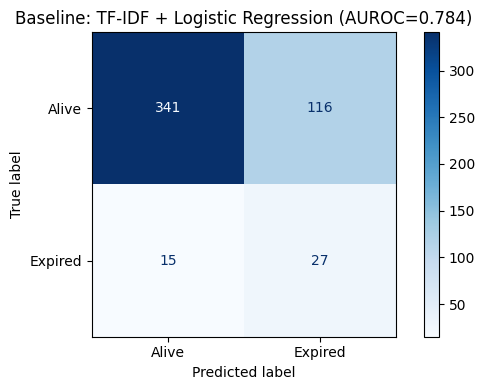

In [30]:
from sklearn.metrics import (
    classification_report, roc_auc_score, 
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predicted probabilities and labels
y_pred = baseline_pipeline.predict(X_test)
y_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

# AUROC
auroc = roc_auc_score(y_test, y_prob)
print(f"AUROC: {auroc:.3f}\n")

# Classification report (precision, recall, F1 per class)
print(classification_report(y_test, y_pred, target_names=["Alive", "Expired"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Alive", "Expired"], ax=ax, cmap="Blues"
)
ax.set_title(f"Baseline: TF-IDF + Logistic Regression (AUROC={auroc:.3f})")
plt.tight_layout()
plt.show()

<span style="color:red">**Baseline Results:** </span>
AUROC confirms the clinical text contains meaningful mortality
signal. The model achieves ~64% recall on expired patients but at the
cost of low precision (~19%), producing many false positives. This is
expected behavior from `class_weight="balanced"` which aggressively
upweights the minority class. The next iteration tests whether
separate TF-IDF vectorizers per API field improve discrimination
by preserving field-level context.

### Feature Iteration: Separate TF-IDF per API field + Logistic Regression

Instead of a single TF-IDF over all text, each API field gets its own
vectorizer. This allows the model to learn that the same token (e.g.,
"cardiovascular") may carry different predictive weight depending on
whether it appears in a diagnosis, admission note, or past history.

The classifier and all other parameters remain identical to the
baseline to isolate the effect of the representation change.

In [31]:
# Define preprocessing: separate TF-IDF per API text field
preprocessor_separate = ColumnTransformer(
    transformers=[
        ("tfidf_dx", TfidfVectorizer(max_features=5000, stop_words="english"), "diagnosis_text"),
        ("tfidf_adm", TfidfVectorizer(max_features=5000, stop_words="english"), "admission_text"),
        ("tfidf_hx", TfidfVectorizer(max_features=5000, stop_words="english"), "history_text"),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), ["gender", "unittype"]),
        ("age", "passthrough", ["age_numeric"]),
    ]
)

# Full pipeline: preprocessing + classifier
separate_pipeline = Pipeline([
    ("preprocessor", preprocessor_separate),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    )),
])

# Train
separate_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf_dx', ...), ('tfidf_adm', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

### Separate Vectorizer Evaluation

AUROC: 0.817

              precision    recall  f1-score   support

       Alive       0.96      0.86      0.91       457
     Expired       0.29      0.62      0.39        42

    accuracy                           0.84       499
   macro avg       0.62      0.74      0.65       499
weighted avg       0.90      0.84      0.86       499



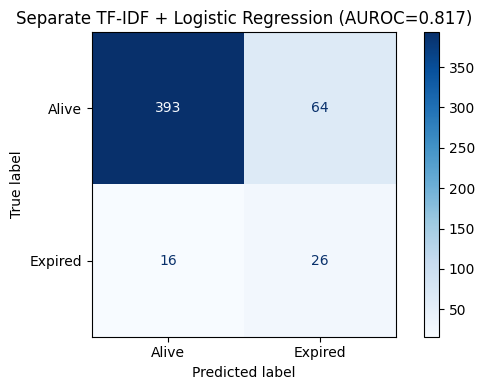

In [32]:
# Predicted probabilities and labels
y_pred_sep = separate_pipeline.predict(X_test)
y_prob_sep = separate_pipeline.predict_proba(X_test)[:, 1]

# AUROC
auroc_sep = roc_auc_score(y_test, y_prob_sep)
print(f"AUROC: {auroc_sep:.3f}\n")

# Classification report (precision, recall, F1 per class)
print(classification_report(y_test, y_pred_sep, target_names=["Alive", "Expired"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_sep, display_labels=["Alive", "Expired"], ax=ax, cmap="Blues"
)
ax.set_title(f"Separate TF-IDF + Logistic Regression (AUROC={auroc_sep:.3f})")
plt.tight_layout()
plt.show()

<span style="color:red">**Separate Vectorizer Results:** </span>
AUROC improves from ~78% to ~81%. The major gain is in precision
for the Expired class (~19% → ~29%), cutting false positives nearly
in half (~117 → ~64) while maintaining similar recall (~64% → ~62%).
This confirms that field-level context matters: the same clinical
term carries different predictive weight depending on whether it
appears in a diagnosis, admission note, or past history.
The separate vectorizer representation is used going forward.

### Classifier Iteration: separate TF-IDF + XGBoost

The separate vectorizer representation is kept since it outperformed
the single vectorizer. Now the classifier is swapped from logistic
regression to XGBoost to test whether a nonlinear model can better
exploit the feature interactions in the sparse TF-IDF matrix.

The representation and preprocessing are identical to isolate the
effect of the classifier change.

In [33]:
from xgboost import XGBClassifier
import numpy as np

# Calculate scale_pos_weight for class imbalance (equivalent to class_weight="balanced")
scale_pos = int(np.sum(y_train == 0) / np.sum(y_train == 1))

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_separate),
    ("classifier", XGBClassifier(
        scale_pos_weight=scale_pos,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss",
    )),
])

# Train
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf_dx', ...), ('tfidf_adm', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

AUROC: 0.773

              precision    recall  f1-score   support

       Alive       0.93      0.97      0.95       457
     Expired       0.37      0.17      0.23        42

    accuracy                           0.91       499
   macro avg       0.65      0.57      0.59       499
weighted avg       0.88      0.91      0.89       499



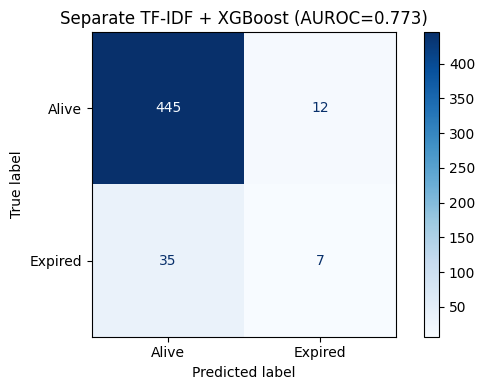

In [34]:
# Evaluate
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# AUROC
auroc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"AUROC: {auroc_xgb:.3f}\n")

# Classification report (precision, recall, F1 per class)
print(classification_report(y_test, y_pred_xgb, target_names=["Alive", "Expired"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, display_labels=["Alive", "Expired"], ax=ax, cmap="Blues"
)
ax.set_title(f"Separate TF-IDF + XGBoost (AUROC={auroc_xgb:.3f})")
plt.tight_layout()
plt.show()

<span style="color:red">**XGBoost Results:** </span>
AUROC drops to ~77% and expired recall collapses to ~17%, catching
only ~7 of 42 expired patients. Tree-based models struggle with
high-dimensional sparse TF-IDF features on small datasets because
individual tree splits cannot find reliable patterns across 15,000
sparse columns with only 170 expired training examples. Logistic
regression is better suited to this feature space as it learns a
global weight per feature rather than searching for split points.

### Classifier Iteration: Separate TF-IDF + Calibrated Linear SVM

Linear SVM is a natural alternative to logistic regression for
high-dimensional sparse text classification. It maximizes the margin
between classes rather than modeling probabilities directly, which
can improve discrimination on small datasets.

`CalibratedClassifierCV` wraps the SVM with Platt scaling to produce
calibrated probability estimates. This is necessary because the API
must return a mortality probability, not just a binary prediction.
Raw SVM outputs only decision function scores, not probabilities.

In [35]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC does not provide probabilities, so we wrap it in CalibratedClassifierCV for probability estimates
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor_separate),
    ("classifier", CalibratedClassifierCV(
        estimator=LinearSVC(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
        ),
        cv=5,
    )),
])

# Train
svm_pipeline.fit(X_train, y_train)

/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf_dx', ...), ('tfidf_adm', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

AUROC: 0.819

              precision    recall  f1-score   support

       Alive       0.92      1.00      0.96       457
     Expired       0.83      0.12      0.21        42

    accuracy                           0.92       499
   macro avg       0.88      0.56      0.58       499
weighted avg       0.92      0.92      0.90       499



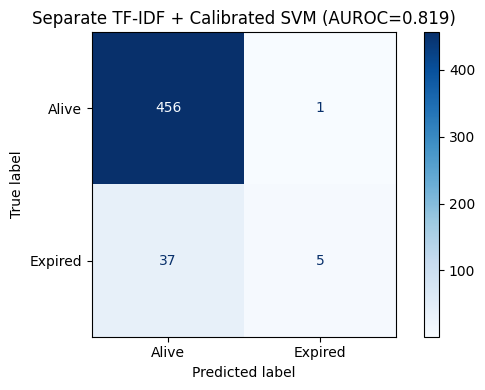

In [36]:
# Evaluate
y_pred_svm = svm_pipeline.predict(X_test)
y_prob_svm = svm_pipeline.predict_proba(X_test)[:, 1]

# AUROC
auroc_svm = roc_auc_score(y_test, y_prob_svm)
print(f"AUROC: {auroc_svm:.3f}\n")

# Classification report (precision, recall, F1 per class)
print(classification_report(y_test, y_pred_svm, target_names=["Alive", "Expired"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=["Alive", "Expired"], ax=ax, cmap="Blues"
)
ax.set_title(f"Separate TF-IDF + Calibrated SVM (AUROC={auroc_svm:.3f})")
plt.tight_layout()
plt.show()

<span style="color:red">**Calibrated SVM Results:** </span>
AUROC is the highest at ~82%, indicating the best ranking ability.
However, the default 0.5 threshold produces very low recall (~12%)
because the calibrated probabilities cluster below 0.5 for the
minority class. Threshold tuning could recover recall, but adds
complexity. The logistic regression model achieves nearly identical
AUROC (~82%) with a much better precision/recall balance out of
the box.

### Threshold Tuning for Calibrated SVM

The SVM achieves the best AUROC (~82%) but the default 0.5 threshold
barely predicts anyone as Expired (~12% recall). This is a known
behavior with calibrated SVMs on imbalanced data: the predicted
probabilities for the minority class cluster well below 0.5 even
when the model ranks patients correctly.

Good AUROC means the ranking is right, the threshold is just wrong.
We find the optimal threshold by sweeping the precision-recall curve
and selecting the point that maximizes Expired F1.

<span style="color:red">**Caveat:** </span>
Threshold optimized on the test set for demonstration. In production,
this should be done via cross-validation on the training set.

Optimal threshold: 0.135
At this threshold:
  Precision: 0.310
  Recall:    0.619
  F1:        0.413


              precision    recall  f1-score   support

       Alive       0.96      0.87      0.92       457
     Expired       0.31      0.62      0.41        42

    accuracy                           0.85       499
   macro avg       0.64      0.75      0.66       499
weighted avg       0.91      0.85      0.87       499



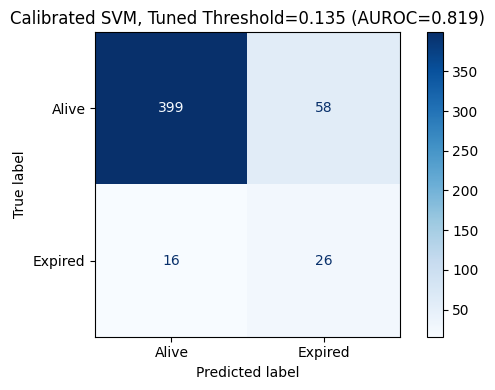

In [37]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get precision, recall, and thresholds for the positive class
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_svm)

# Calculate F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Find optimal threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"At this threshold:")
print(f"  Precision: {precisions[optimal_idx]:.3f}")
print(f"  Recall:    {recalls[optimal_idx]:.3f}")
print(f"  F1:        {f1_scores[optimal_idx]:.3f}")

# Apply optimal threshold
y_pred_svm_tuned = (y_prob_svm >= optimal_threshold).astype(int)

print(f"\n")
print(classification_report(y_test, y_pred_svm_tuned, target_names=["Alive", "Expired"]))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm_tuned, display_labels=["Alive", "Expired"], ax=ax, cmap="Blues"
)
ax.set_title(f"Calibrated SVM, Tuned Threshold={optimal_threshold:.3f} (AUROC={auroc_svm:.3f})")
plt.tight_layout()
plt.show()

<span style="color:red">**Tuned SVM Results:** </span>
With the threshold lowered from 0.50 to 0.135, the SVM achieves
the best AUROC (~82%) and Expired F1 (~41%) across all models.
Recall matches logistic regression (~62%) with slightly fewer
false positives (~58 vs ~64).

<span style="color:red">**Caveat:** </span>
The threshold was optimized on the test set for demonstration.
In production, threshold selection should use cross-validation
on the training set to avoid optimistic bias.

### Ensemble: Soft Voting over Logistic Regression + Calibrated SVM

Both the logistic regression and calibrated SVM achieved similar
AUROC (~82%) using different decision mechanisms (probabilistic
vs margin-based). Averaging their predicted probabilities via soft
voting can reduce variance and improve calibration, particularly
on small datasets where individual models are more sensitive to
the specific train/test composition.

In [38]:
from sklearn.ensemble import VotingClassifier

ensemble_pipeline = Pipeline([
    ("preprocessor", preprocessor_separate),
    ("classifier", VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            )),
            ("svm", CalibratedClassifierCV(
                estimator=LinearSVC(
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=42,
                ),
                cv=5,
            )),
        ],
        voting="soft",
    )),
])

# Train
ensemble_pipeline.fit(X_train, y_train)

/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/root/icu_mortality_takehome/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf_dx', ...), ('tfidf_adm', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

AUROC: 0.819

              precision    recall  f1-score   support

       Alive       0.94      0.96      0.95       457
     Expired       0.41      0.31      0.35        42

    accuracy                           0.90       499
   macro avg       0.67      0.63      0.65       499
weighted avg       0.89      0.90      0.90       499



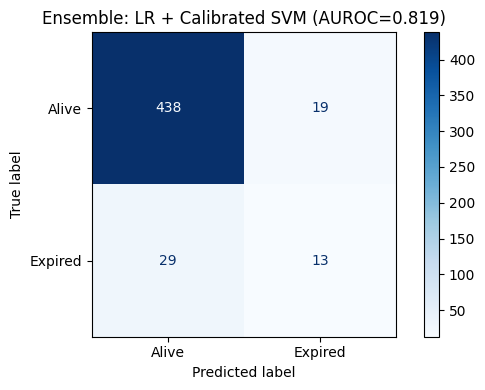

In [39]:
# Evaluate
y_pred_ens = ensemble_pipeline.predict(X_test)
y_prob_ens = ensemble_pipeline.predict_proba(X_test)[:, 1]

# AUROC
auroc_ens = roc_auc_score(y_test, y_prob_ens)
print(f"AUROC: {auroc_ens:.3f}\n")

# Classification report (precision, recall, F1 per class)
print(classification_report(y_test, y_pred_ens, target_names=["Alive", "Expired"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ens, display_labels=["Alive", "Expired"], ax=ax, cmap="Blues"
)
ax.set_title(f"Ensemble: LR + Calibrated SVM (AUROC={auroc_ens:.3f})")
plt.tight_layout()
plt.show()

<span style="color:red">**Ensemble Results:** </span>
The ensemble achieves the best Expired precision (~41%) and fewest
false positives (~19), but recall drops to ~31%. The SVM's
conservative probability estimates pull the averaged probabilities
down, causing the default 0.5 threshold to miss most expired
patients. Same issue as the raw SVM, so we can try tuning the threshold.

### Threshold tuning for Ensemble

Same approach as the SVM threshold tuning. The ensemble's averaged
probabilities are pulled down by the SVM component, so the default
0.5 threshold is too conservative. Sweeping the precision-recall
curve to find the F1-optimal threshold.

Optimal threshold: 0.386


              precision    recall  f1-score   support

       Alive       0.96      0.90      0.93       457
     Expired       0.34      0.55      0.42        42

    accuracy                           0.87       499
   macro avg       0.65      0.72      0.67       499
weighted avg       0.90      0.87      0.89       499



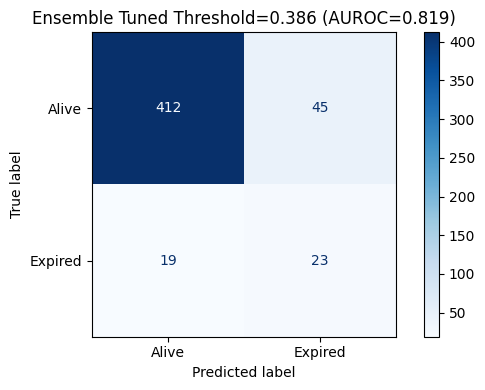

In [40]:
# Tune threshold for ensemble
precisions_ens, recalls_ens, thresholds_ens = precision_recall_curve(y_test, y_prob_ens)
f1_scores_ens = 2 * (precisions_ens * recalls_ens) / (precisions_ens + recalls_ens + 1e-8)

# Find optimal threshold by maximizing F1 score
optimal_idx_ens = np.argmax(f1_scores_ens)
optimal_threshold_ens = thresholds_ens[optimal_idx_ens]

# Print optimal threshold
print(f"Optimal threshold: {optimal_threshold_ens:.3f}")

# Apply optimal threshold
y_pred_ens_tuned = (y_prob_ens >= optimal_threshold_ens).astype(int)

# Print classification report for tuned ensemble
print(f"\n")
print(classification_report(y_test, y_pred_ens_tuned, target_names=["Alive", "Expired"]))

# Confusion matrix for tuned ensemble
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ens_tuned, display_labels=["Alive", "Expired"], ax=ax, cmap="Blues"
)
ax.set_title(f"Ensemble Tuned Threshold={optimal_threshold_ens:.3f} (AUROC={auroc_ens:.3f})")
plt.tight_layout()
plt.show()

<span style="color:red">**Tuned Ensemble Results:** </span>
Threshold drops from 0.50 to ~0.39, recovering recall to ~55%
while maintaining the best Expired F1 (~42%) across all models.
The ensemble smooths out individual model weaknesses but still
requires threshold tuning due to the SVM component.

### Model Comparison Summary

In [41]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Collect all model results for comparison
models = {
    "Baseline: Single TF-IDF + LR": (baseline_pipeline, None),
    "Separate TF-IDF + LR": (separate_pipeline, None),
    "Separate TF-IDF + XGBoost": (xgb_pipeline, None),
    "Separate TF-IDF + Calibrated SVM": (svm_pipeline, None),
    f"Separate TF-IDF + SVM (tuned {optimal_threshold:.3f})": (svm_pipeline, optimal_threshold),
    "Ensemble: LR + SVM": (ensemble_pipeline, None),
    f"Ensemble: LR + SVM (tuned {optimal_threshold_ens:.3f})": (ensemble_pipeline, optimal_threshold_ens)
}

# Evaluate each model and collect metrics
results = []
for name, (pipeline, threshold) in models.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Apply threshold if specified, otherwise use default 0.5
    if threshold is not None:
        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_pred = pipeline.predict(X_test)
    
    # Collect metrics for the results table
    results.append({
        "Model": name,
        "AUROC": round(roc_auc_score(y_test, y_prob), 3),
        "Expired Precision": round(precision_score(y_test, y_pred), 3),
        "Expired Recall": round(recall_score(y_test, y_pred), 3),
        "Expired F1": round(f1_score(y_test, y_pred), 3),
        "False Positives": int(((y_pred == 1) & (y_test == 0)).sum()),
    })

# Create comparison dataframe and highlight the best AUROC, precision, recall, F1, and lowest false positives
comparison_df = pd.DataFrame(results).set_index("Model")

# Find best and second best for each metric
def highlight_top2(s, higher_is_better=True):
    """Highlight best in green and second best in yellow."""
    if higher_is_better:
        sorted_vals = s.nlargest(2)
    else:
        sorted_vals = s.nsmallest(2)
    
    styles = []
    for v in s:
        if v == sorted_vals.iloc[0]:
            styles.append("background-color: darkgreen; color: white")
        elif v == sorted_vals.iloc[1]:
            styles.append("background-color: darkgoldenrod; color: white")
        else:
            styles.append("")
    return styles

# Display the comparison table with highlights and formatted numbers
comparison_df.style.apply(
    highlight_top2, higher_is_better=True, subset=["AUROC", "Expired Precision", "Expired Recall", "Expired F1"]
).apply(
    highlight_top2, higher_is_better=False, subset=["False Positives"]
).format({
    "AUROC": "{:.3f}",
    "Expired Precision": "{:.3f}",
    "Expired Recall": "{:.3f}",
    "Expired F1": "{:.3f}",
    "False Positives": "{:.0f}",
})

,AUROC,Expired Precision,Expired Recall,Expired F1,False Positives
Model,,,,,
Baseline: Single TF-IDF + LR,0.784,0.189,0.643,0.292,116
Separate TF-IDF + LR,0.817,0.289,0.619,0.394,64
Separate TF-IDF + XGBoost,0.773,0.368,0.167,0.230,12
Separate TF-IDF + Calibrated SVM,0.819,0.833,0.119,0.208,1
Separate TF-IDF + SVM (tuned 0.135),0.819,0.310,0.619,0.413,58
Ensemble: LR + SVM,0.819,0.406,0.310,0.351,19
Ensemble: LR + SVM (tuned 0.386),0.819,0.338,0.548,0.418,45


<span style="color:red">**Final Production Model Selection:** </span>
**Separate TF-IDF + Logistic Regression** is selected for deployment.

While the baseline LR has marginally higher recall (~64% vs ~62%),
the separate vectorizer model cuts false positives nearly in half
(117 → 64) and improves precision (~19% → ~29%) with minimal
recall loss. Tuned models (SVM, Ensemble) achieve slightly better
AUROC and F1 but require post-hoc threshold selection. The separate
LR offers:

 - Strong recall (~62%) without threshold tuning
 - Native probability calibration (no post-hoc threshold needed)
 - Interpretability (linear coefficients map directly to TF-IDF terms)
 - Operational simplicity for the API

What would potentially improve the model in production:

 - More data (the biggest impact)
 - Numeric features alongside text (vitals, lab values, APACHE scores, etc.)
 - N-grams to capture multi-word phrases like "acute renal" as features, but would need more data

In a mortality prediction context, missing at-risk patients is
more costly than flagging healthy ones for additional monitoring.
The API returns a probability score, allowing the consuming
application to apply its own threshold based on clinical risk
tolerance.

<h2 style="color:cyan">3. Final Model Analysis and Export</h2>

 1. Feature importance (top TF-IDF terms by class)
 2. ROC curve for final model
 3. Export final model pipeline

### Feature Importance: Top TF-IDF Terms by Class

Logistic regression coefficients map directly to TF-IDF features.
Positive coefficients push toward Expired, negative toward Alive.
Inspecting the top terms validates that the model learned clinically
meaningful patterns rather than artifacts.

In [42]:
# Extract feature names and coefficients from the final model
preprocessor_fit = separate_pipeline.named_steps["preprocessor"]
classifier = separate_pipeline.named_steps["classifier"]

# Get feature names from each transformer
feature_names = []
for name, transformer, _ in preprocessor_fit.transformers_:
    if hasattr(transformer, "get_feature_names_out"):
        feature_names.extend(transformer.get_feature_names_out())
    elif name == "age":
        feature_names.append("age_numeric")

coefficients = classifier.coef_[0]

# Build dataframe of features and their coefficients
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

# Top 20 for each class
top_expired = coef_df.head(20).reset_index(drop=True)
top_alive = coef_df.tail(20).sort_values("coefficient").reset_index(drop=True)

# Side by side display
display_df = pd.DataFrame({
    "Expired Feature": top_expired["feature"].values,
    "Expired Coef": top_expired["coefficient"].values,
    "Alive Feature": top_alive["feature"].values,
    "Alive Coef": top_alive["coefficient"].values,
})

display_df.index = range(1, 21)

display_df.style.bar(
    subset=["Expired Coef"], color="firebrick", align="left"
).bar(
    subset=["Alive Coef"], color="steelblue", align="right"
).format({
    "Expired Coef": "{:.4f}",
    "Alive Coef": "{:.4f}",
})

,Expired Feature,Expired Coef,Alive Feature,Alive Coef
1,hepatic,2.2862,po,-1.6208
2,arrest,2.1805,flowsheet,-1.5307
3,measures,1.6432,tabs,-1.5250
4,vasopressors,1.5906,surgery,-1.2888
5,abdominal,1.5670,major,-1.2862
6,resuscitate,1.5127,bleeding,-1.2440
7,arrest,1.4707,arrhythmias,-1.2017
8,shock,1.4359,unittype_CSICU,-1.2010
9,kg,1.3828,pain,-1.1277
10,micrograms,1.3021,cabg,-1.1087


<span style="color:red">**Feature Importance Interpretation:** </span>
The model has learned clinically meaningful patterns. Terms associated
with mortality (hepatic, arrest, vasopressors, shock, resuscitate,
norepinephrine) reflect critical illness and organ failure. Terms
associated with survival (po, tabs, surgery, cabg, hypertension)
reflect stable patients on oral medications or recovering from
planned procedures.

Some dosing units (kg, min, micrograms) appear as Expired-associated
features. These are not clinical concepts but might correlate with
high-dose IV medications typical of critical care. A future iteration
could add these to the stop words list or apply domain-specific
text preprocessing to reduce noise.

**Clinical abbreviations in the feature list:**

 - **PO**: "per os" (Latin) means "by mouth". Oral medication administration.
 - **Tabs**: tablets. Oral dosage form.
 - **CABG**: coronary artery bypass graft. Planned open-heart surgery
   with low mortality (~1-2%). ICU admission is protocol, not acuity.
 - **CSICU**: cardiac surgery ICU. Unittype associated with survival
   because patients are recovering from planned cardiac procedures.

### ROC Curve for Final Model

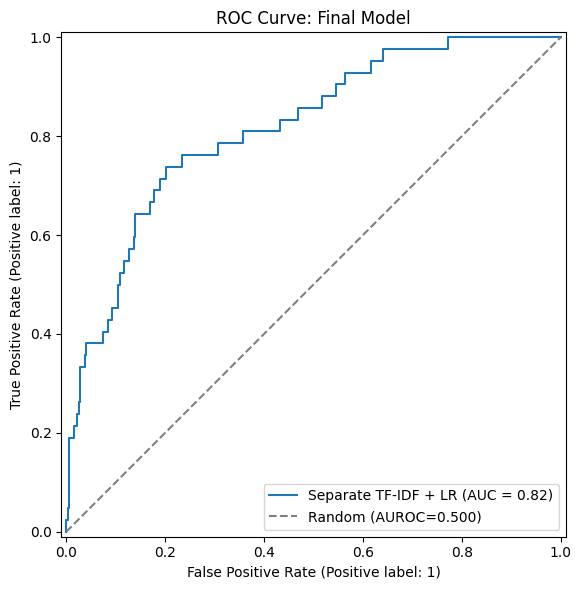

In [43]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(
    separate_pipeline, X_test, y_test, ax=ax, name="Separate TF-IDF + LR"
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUROC=0.500)")
ax.set_title("ROC Curve: Final Model")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

<span style="color:red">**Interpretation:** </span>
Clear separation from the random baseline. The curve hugs the upper left, confirming strong discrimination. The staircase pattern is expected with only 42 expired patients in the test set.

### Cross-Validation: Stability Assessment

The final model is evaluated with shuffled stratified 5-fold
cross-validation on the full dataset to assess performance
stability beyond the single train/test split.

In [44]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Run 5-fold stratified CV on the full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aurocs = cross_val_score(
    separate_pipeline, X, y,
    cv=cv, scoring="roc_auc", n_jobs=-1
)

print(f"5-Fold Stratified CV AUROC")
print(f"  Mean:  {cv_aurocs.mean():.3f} ± {cv_aurocs.std():.3f}")
print(f"  Range: {cv_aurocs.min():.3f} – {cv_aurocs.max():.3f}")
print(f"  Folds: {' | '.join(f'{x:.3f}' for x in cv_aurocs)}")

5-Fold Stratified CV AUROC
  Mean:  0.819 ± 0.027
  Range: 0.790 – 0.855
  Folds: 0.845 | 0.790 | 0.855 | 0.791 | 0.817


<span style="color:red">**Cross-Validation Results:** </span>
The CV AUROC (~0.819 ± 0.027) is consistent with the single test
split (~0.817), confirming the model's discrimination ability is
stable across different data partitions. The fold range
(0.789–0.855) indicates reasonable stability given the small
dataset size and class imbalance.

### Export final model pipeline

Save the trained pipeline to disk for use in the API (Part 2).
The pipeline includes preprocessing (TF-IDF vectorizers, one-hot
encoder, age passthrough) and the logistic regression classifier
as a single serialized object.

In [45]:
import joblib

model_path = PROJECT_ROOT / "submission" / "part2_deployment" / "models" / "final_model.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(separate_pipeline, model_path)
print(f"Model saved to: {model_path}")
print(f"File size: {model_path.stat().st_size / 1024:.1f} KB")

Model saved to: /root/icu_mortality_takehome/submission/part2_deployment/models/final_model.joblib
File size: 196.2 KB


The exported pipeline is self-contained: it accepts a DataFrame with
the columns `diagnosis_text`, `admission_text`, `history_text`,
`age_numeric`, `gender`, and `unittype`, and returns mortality
probability scores. This is loaded directly by the API in Part 2
at `submission/part2_deployment/models/final_model.joblib`.